In [ ]:
import numpy as np

from tools.circuits import generate_steane_circuit 
from tools.error_models import  construct_circuit_noise_model
from tools.syndrome_prediction import generate_log_error_rates_diff_p, predict_ML, predict_MWPM 

In [2]:
import tools.graphics as graphic 
from importlib import reload
reload(graphic)

<module 'tools.graphics' from '/home/leo/Documents/MasterArbeit/code/tools/graphics.py'>

In [ ]:
distances = [3,5]
noise_set = np.logspace(-3.5,-0.9, num=10)
num_shots = 20_000 
noise_model = "circ"
noise_func = construct_circuit_noise_model

def func_shortcut_rounds(rounds, count_logical_func=predict_ML):
    steane_circuits = [generate_steane_circuit(d, rounds=rounds) for d in distances]

    return generate_log_error_rates_diff_p(
    steane_circuits,
    noise_model_fct=noise_func,
    count_log_error_fct=count_logical_func,
    distances= distances ,
    rounds=rounds,
    noise_set= noise_set,
    num_shots= num_shots,
    noise_model=noise_model,
    )

In [ ]:
# MWPM
max_rounds = 20 

rounds = np.arange(1, max_rounds + 1) 
log_error_rates_r_MWPM = [[]] * max_rounds
y_errs_r_MWPM = [[]] * max_rounds

for i_round, round in enumerate(rounds):
    log_error_rates_r_MWPM[i_round], y_errs_r_MWPM[i_round] = func_shortcut_rounds(round, count_logical_func=decode_syndromes_MWPM)



<Figure size 640x480 with 0 Axes>

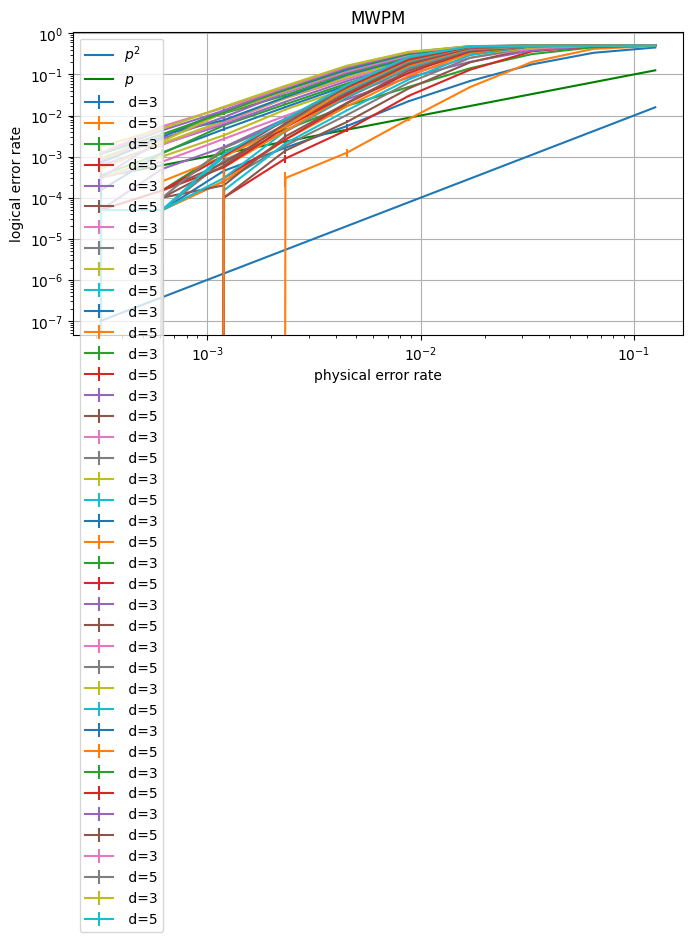

In [5]:
graphic.overlay_different_slopes(
    log_error_rates_r_MWPM,
    y_errs_r_MWPM, 
    distances=distances,
    noise_set=noise_set,
    # titles=["1 Round"] + [f"{i} Rounds" for i in np.arange(2,len(log_error_rates_r_MWPM)+1)],
    title="MWPM",
    reference_lines= True,
)

In [ ]:
# ML 
max_rounds = 4

rounds = np.arange(1, max_rounds + 1) 
log_error_rates_r_ML = [[]] * max_rounds
y_errs_r_ML = [[]] * max_rounds

for i_round, round in enumerate(rounds):
    log_error_rates_r_ML[i_round], y_errs_r_ML[i_round] = func_shortcut_rounds(round, count_logical_func=predict_ML)


<Figure size 640x480 with 0 Axes>

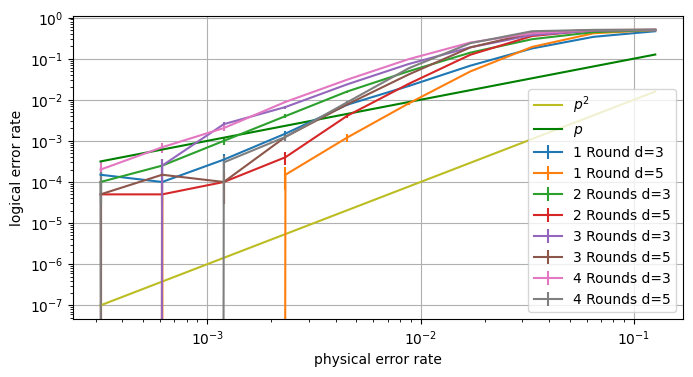

In [7]:
graphic.overlay_different_slopes(
    log_error_rates_r_ML,
    y_errs_r_ML, 
    distances=distances,
    noise_set=noise_set,
    titles=["1 Round", "2 Rounds", "3 Rounds", "4 Rounds"],
    reference_lines= True,
)